STEP ONE

The Roblox Dataset contains information on 9,734 Roblox games and 16 features, including game popularity, player engagement, genre, creator details, and game statistics. It is suitable for exploratory data analysis and machine learning projects.

STEP TWO

Problem definition

what is the dataset about:

The Roblox Dataset is a collection of information about 9,734 Roblox games gathered through web scraping. It includes 16 features that describe different aspects of each game, such as:

Game information: title, creator, genre, age recommendation, and server size.
Popularity metrics: total visits, favorites, active players, likes, and dislikes.
Game features: whether voice chat or Camera are supported and other gameplay-related metadata.
Time-related data: creation date and last update date.


---



what main questions will you explore:

Which game genres are the most popular among certain age?

Does supporting features like voice chat or camera affect popularity?

Which creators publish the most successful games?

what is the least liked genre?

what is the most liked genre?


---
What insights do you expect to uncover?


Identify genres that attract the highest number of visits, favorites, and active players.

Assess whether games with additional features attract more players and engagement

Identify creators with consistently high-performing games and compare their popularity metrics.

determine the most and least favorite Genre

STEP THREE

# Data Loading & Structure

Importing Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
#Reading Dataset from CSV file
dataset = pd.read_csv('roblox_games_data.csv')

In [40]:
#Displaying the 5 rows
dataset.head()

,Title,Creator,AgeRecommendation,Active,Favorites,Visits,VoiceChat,Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes,GameLink,DateFetched
0,Catalog Avatar Creator,@ItsMuneeeb,All Ages,19469,3438844,2.8B+,Supported,Supported,7/4/2021,11/5/2024,24,Shopping,1M+,124K+,https://www.roblox.com/games/7041939546/Catalo...,11/5/2024 20:24
1,[HALLOWEEN 🎃] The Mimic,CTStudio,Ages 13+,2709,2911356,988.3M+,Supported,Not Supported,1/15/2021,11/5/2024,45,Survival,982K+,107K+,https://www.roblox.com/games/6243699076/HALLOW...,11/5/2024 20:25
2,[RANKED + MORE] Frisbee Frenzy,johnny cage fan group,All Ages,148,21024,1.5M+,Supported,Not Supported,10/26/2023,11/5/2024,8,NaN,5265,1011,https://www.roblox.com/games/15170454486/RANKE...,11/5/2024 20:25
3,PIGGY: MiniToon Edition [EPISODE 2!],@TaintedMod,All Ages,0,4,44,Not Supported,Not Supported,5/31/2024,7/21/2024,6,NaN,3,0,https://www.roblox.com/games/17681545435/PIGGY...,11/5/2024 20:25
4,Sol's RNG [Era 9],sol's studio,All Ages,22155,635262,765.9M+,Supported,Not Supported,12/3/2023,11/4/2024,20,Simulation,746K+,101K+,https://www.roblox.com/games/15532962292/Sols-...,11/5/2024 20:25


In [41]:
#Printing the name of the columns
dataset.columns

Index(['Title', 'Creator', 'AgeRecommendation', 'Active', 'Favorites',
       'Visits', 'VoiceChat', 'Camera', 'Created', 'Updated', 'ServerSize',
       'Genre', 'Likes', 'Dislikes', 'GameLink', 'DateFetched'],
      dtype='object')

In [42]:
#Shape of the data
dataset.shape

(9734, 16)

The dataset contains 9734 rows and 16 columns

In [43]:
#Checking if there is null values and the data type of each column
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9734 entries, 0 to 9733
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Title              9734 non-null   object
 1   Creator            9734 non-null   object
 2   AgeRecommendation  9734 non-null   object
 3   Active             9734 non-null   int64 
 4   Favorites          9734 non-null   int64 
 5   Visits             9734 non-null   object
 6   VoiceChat          9734 non-null   object
 7   Camera             9734 non-null   object
 8   Created            9734 non-null   object
 9   Updated            9734 non-null   object
 10  ServerSize         9734 non-null   int64 
 11  Genre              6914 non-null   object
 12  Likes              9734 non-null   object
 13  Dislikes           9734 non-null   object
 14  GameLink           9734 non-null   object
 15  DateFetched        9734 non-null   object
dtypes: int64(3), object(13)
memory usage: 1.2+

In [44]:
#Printing the statistical summary of numerical columns
dataset.describe()

,Active,Favorites,ServerSize
count,9734.000000,9.734000e+03,9734.000000
mean,3711.214609,1.008865e+06,24.926752
std,23406.152600,2.636969e+06,24.800954
min,0.000000,0.000000e+00,1.000000
25%,76.000000,1.227000e+04,10.000000
50%,595.000000,1.394295e+05,16.000000
75%,1626.750000,7.744932e+05,30.000000
max,697429.000000,2.873764e+07,700.000000


In [45]:
#Checking for null values and summing them
dataset.isnull().sum()

Title                   0
Creator                 0
AgeRecommendation       0
Active                  0
Favorites               0
Visits                  0
VoiceChat               0
Camera                  0
Created                 0
Updated                 0
ServerSize              0
Genre                2820
Likes                   0
Dislikes                0
GameLink                0
DateFetched             0
dtype: int64

There are 2820 null values in the Genre column

Step 4: Data Cleaning

Handling Missing Values

In [46]:
#Checking the Percentage of null values
(dataset.isnull().sum()/ len(dataset))* 100


Title                 0.000000
Creator               0.000000
AgeRecommendation     0.000000
Active                0.000000
Favorites             0.000000
Visits                0.000000
VoiceChat             0.000000
Camera                0.000000
Created               0.000000
Updated               0.000000
ServerSize            0.000000
Genre                28.970618
Likes                 0.000000
Dislikes              0.000000
GameLink              0.000000
DateFetched           0.000000
dtype: float64

The Genre column is a categorical variable with approximately 28% missing values. Since Genre is an important feature for the exploratory analysis, removing the rows with missing values would result in a substantial loss of data. Therefore, I imputed the missing values using the mode (most frequent genre), which is a common technique for categorical variables.

This approach preserves the dataset size and allows genre-based analyses to be performed, although it may slightly increase the frequency of the most common genre and introduce some bias.

In [47]:
dataset['Genre'] = dataset['Genre'].fillna(value = dataset['Genre'].mode()[0])

Limitation for this approach:
Because nearly one-third of the Genre values were missing, mode imputation may overrepresent the most common genre.

In [48]:
#Ensuring the null values has been filled
dataset.isnull().sum()

Title                0
Creator              0
AgeRecommendation    0
Active               0
Favorites            0
Visits               0
VoiceChat            0
Camera               0
Created              0
Updated              0
ServerSize           0
Genre                0
Likes                0
Dislikes             0
GameLink             0
DateFetched          0
dtype: int64

Checking for Duplicates

In [49]:
dataset.duplicated().sum()

0

There is no duplicated variables

Converting data types

Removing the " + " from ['Visits', 'Likes', 'Dislikes'] in the process of converting them into numeric instead of objects

In [50]:

dataset['Visits'] = dataset['Visits'].str.replace('+', "")
dataset['Likes'] = dataset['Likes'].str.replace('+', "")
dataset['Dislikes'] = dataset['Dislikes'].str.replace('+', "")


This function converts abbreviated numeric values into their actual numeric form. It checks whether a value contains 'K' (thousand), 'M' (million), or 'B' (billion). The suffix is removed, and the remaining number is multiplied by the corresponding factor (1,000, 1,000,000, or 1,000,000,000). If the value does not contain any of these suffixes, it is simply converted to a floating-point number.

In [51]:
def convert(x):
  if "K" in x:
    return float(x.replace("K", "")) * 1000
  elif "M" in x:
    return float(x.replace("M", "")) * 1000000
  elif "B" in x:
    return float(x.replace("B", "")) * 1000000000
  else:
    return float(x)



Reason : converting abbreviated values (K, M, and B) into full numeric values so they can be analyzed correctly. Numeric data is required for calculations, statistical analysis, and visualizations.

In [52]:
dataset['Visits'] = dataset['Visits'].apply(lambda x : convert(x))
dataset['Likes'] = dataset['Likes'].apply(lambda x : convert(x))
dataset['Dislikes'] = dataset['Dislikes'].apply(lambda x : convert(x))


Converting ['VoiceChat', 'Camera'] into 0 and 1

In [53]:
dataset['VoiceChat'] = np.where(dataset['VoiceChat'] == 'Supported', 1, 0)

In [54]:
dataset['Camera'] = np.where(dataset['Camera'] == 'Supported', 1, 0)

Removing @ from the creator names to standardize the data and make the creator names easier to read and analyze.

In [55]:
dataset['Creator'] = dataset['Creator'].str.replace("@", "")

The DateFetched and GameLink columns were removed because they are not relevant to the analysis

In [56]:
del dataset['DateFetched']

In [57]:
del dataset['GameLink']

Converting Created and Updated from objects to dates

In [58]:
dataset['Created'] = pd.to_datetime(dataset['Created'],errors='coerce')
dataset['Updated'] = pd.to_datetime(dataset['Updated'],  errors='coerce')

Checking all the changes that have been applied to my dataset

In [59]:
dataset

,Title,Creator,AgeRecommendation,Active,Favorites,Visits,VoiceChat,Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes
0,Catalog Avatar Creator,ItsMuneeeb,All Ages,19469,3438844,2.800000e+09,1,1,2021-07-04,2024-11-05,24,Shopping,1000000.0,124000.0
1,[HALLOWEEN 🎃] The Mimic,CTStudio,Ages 13+,2709,2911356,9.883000e+08,1,0,2021-01-15,2024-11-05,45,Survival,982000.0,107000.0
2,[RANKED + MORE] Frisbee Frenzy,johnny cage fan group,All Ages,148,21024,1.500000e+06,1,0,2023-10-26,2024-11-05,8,Simulation,5265.0,1011.0
3,PIGGY: MiniToon Edition [EPISODE 2!],TaintedMod,All Ages,0,4,4.400000e+01,0,0,2024-05-31,2024-07-21,6,Simulation,3.0,0.0
4,Sol's RNG [Era 9],sol's studio,All Ages,22155,635262,7.659000e+08,1,0,2023-12-03,2024-11-04,20,Simulation,746000.0,101000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9729,Yeet A Friend!,Low Effort Studios.,All Ages,2423,998236,3.509000e+08,0,0,2022-12-01,2024-11-12,12,Simulation,639000.0,34000.0
9730,Yoinkz! [2-Player],Worried Productions (ROBLOX),All Ages,301,63555,1.600000e+06,0,0,2024-09-28,2024-10-28,30,Simulation,4044.0,601.0
9731,ZO SAMURAI SWORD FIGHTING,ZO by Voldex,Ages 9+,1283,1572897,5.488000e+08,0,0,2021-04-14,2024-11-07,25,Action,684000.0,146000.0
9732,Zombie Attack,Zombie Attack Official,Ages 9+,1072,5771457,1.600000e+09,0,0,2017-12-12,2024-10-14,8,Survival,1000000.0,79000.0


Feature Engineering

In [60]:
dataset['YearsSinceCreation'] = dataset['Updated'].dt.year - dataset['Created'].dt.year

Game Age was calculated to determine how long each game has existed.

In [61]:
dataset['Ratio_Likes'] = dataset['Likes'] / (dataset['Likes'] +  dataset['Dislikes'])

The Like Ratio was calculated to measure the proportion of positive feedback relative to the total number of ratings (likes and dislikes). This provides a better indicator of player satisfaction than using likes alone.

In [62]:
dataset['Ratio_Dislikes'] = 1- dataset['Ratio_Likes']

The Dislike Ratio was calculated to measure the proportion of negative feedback relative to the total number of ratings.

In [63]:
#Check data after adding new columns
dataset

,Title,Creator,AgeRecommendation,Active,Favorites,Visits,VoiceChat,Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes,YearsSinceCreation,Ratio_Likes,Ratio_Dislikes
0,Catalog Avatar Creator,ItsMuneeeb,All Ages,19469,3438844,2.800000e+09,1,1,2021-07-04,2024-11-05,24,Shopping,1000000.0,124000.0,3,0.889680,0.110320
1,[HALLOWEEN 🎃] The Mimic,CTStudio,Ages 13+,2709,2911356,9.883000e+08,1,0,2021-01-15,2024-11-05,45,Survival,982000.0,107000.0,3,0.901745,0.098255
2,[RANKED + MORE] Frisbee Frenzy,johnny cage fan group,All Ages,148,21024,1.500000e+06,1,0,2023-10-26,2024-11-05,8,Simulation,5265.0,1011.0,1,0.838910,0.161090
3,PIGGY: MiniToon Edition [EPISODE 2!],TaintedMod,All Ages,0,4,4.400000e+01,0,0,2024-05-31,2024-07-21,6,Simulation,3.0,0.0,0,1.000000,0.000000
4,Sol's RNG [Era 9],sol's studio,All Ages,22155,635262,7.659000e+08,1,0,2023-12-03,2024-11-04,20,Simulation,746000.0,101000.0,1,0.880756,0.119244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9729,Yeet A Friend!,Low Effort Studios.,All Ages,2423,998236,3.509000e+08,0,0,2022-12-01,2024-11-12,12,Simulation,639000.0,34000.0,2,0.949480,0.050520
9730,Yoinkz! [2-Player],Worried Productions (ROBLOX),All Ages,301,63555,1.600000e+06,0,0,2024-09-28,2024-10-28,30,Simulation,4044.0,601.0,0,0.870614,0.129386
9731,ZO SAMURAI SWORD FIGHTING,ZO by Voldex,Ages 9+,1283,1572897,5.488000e+08,0,0,2021-04-14,2024-11-07,25,Action,684000.0,146000.0,3,0.824096,0.175904
9732,Zombie Attack,Zombie Attack Official,Ages 9+,1072,5771457,1.600000e+09,0,0,2017-12-12,2024-10-14,8,Survival,1000000.0,79000.0,7,0.926784,0.073216


In [ ]:
dataset.to_csv('Cleaned_Data.csv', index=False)

In [65]:
dataset[dataset['Likes'] == dataset['Likes'].max()].iloc[0]


Title                         Blox Fruits
Creator                   Gamer Robot Inc
AgeRecommendation                 Ages 9+
Active                             520438
Favorites                        13644516
Visits                      41700000000.0
VoiceChat                               0
Camera                                  0
Created               2019-01-16 00:00:00
Updated               2024-11-05 00:00:00
ServerSize                             12
Genre                                 RPG
Likes                           8000000.0
Dislikes                         685000.0
YearsSinceCreation                      5
Ratio_Likes                      0.921128
Ratio_Dislikes                   0.078872
Name: 403, dtype: object

In [66]:
dataset[dataset['Likes'] == dataset['Likes'].min()].iloc[0]


Title                             DENSITY
Creator                        Melanak_84
AgeRecommendation                All Ages
Active                                  0
Favorites                               0
Visits                               13.0
VoiceChat                               0
Camera                                  1
Created               2024-03-03 00:00:00
Updated               2024-03-22 00:00:00
ServerSize                             50
Genre                          Simulation
Likes                                 0.0
Dislikes                              0.0
YearsSinceCreation                      0
Ratio_Likes                           NaN
Ratio_Dislikes                        NaN
Name: 77, dtype: object

# Step 5: Exploratory Data Analysis (EDA)

Univariate

c:\Users\forev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


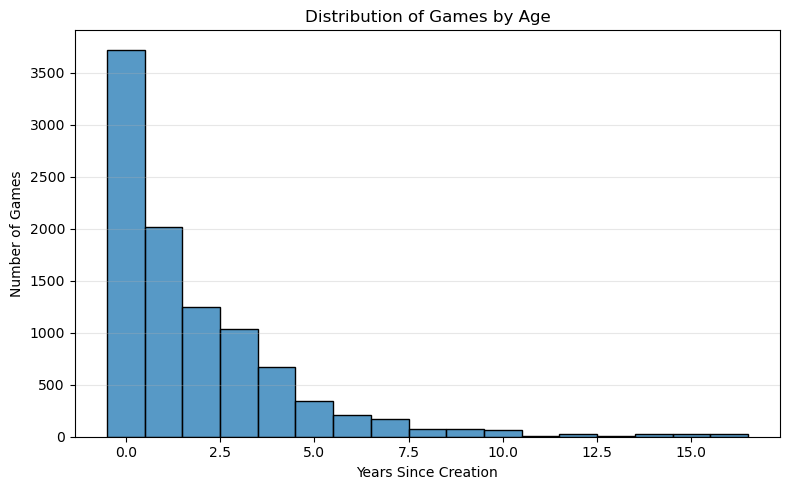

In [67]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=dataset,
    x='YearsSinceCreation',
    bins=range(0,18),
    discrete=True
)

plt.title("Distribution of Games by Age")
plt.xlabel("Years Since Creation")
plt.ylabel("Number of Games")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The histogram shows that the distribution of Years Since Creation is highly right-skewed. Most Roblox games are newly created, with the highest number of games being less than one year old. As the age of the games increases, the number of games decreases steadily. Only a small number of games have been active for more than 10 years, indicating that long-standing games are relatively rare in the dataset.

c:\Users\forev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


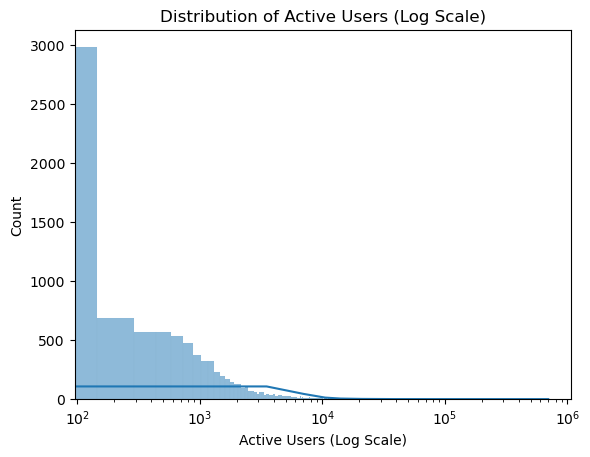

In [68]:
sns.histplot(dataset['Active'], kde=True)
plt.title("Distribution of Active Users (Log Scale)")
plt.xscale('log')
plt.xlabel("Active Users (Log Scale)")

plt.show()

The distribution of Active Players is highly right-skewed, with the vast majority of Roblox games having a relatively small number of active players. Only a few games have exceptionally high numbers of concurrent player

<Axes: xlabel='Genre'>

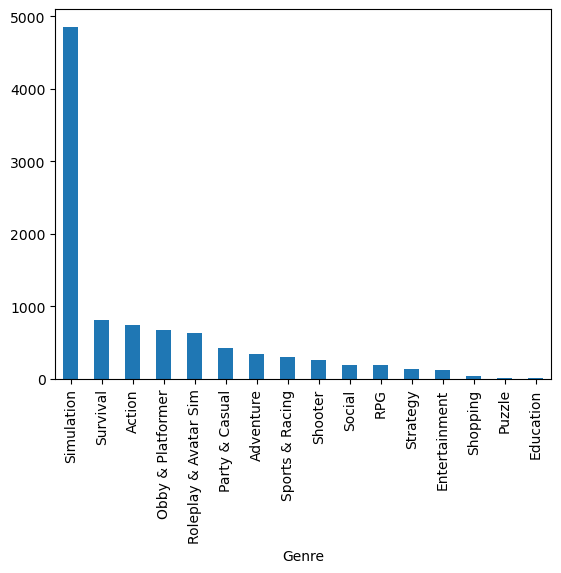

In [69]:
dataset["Genre"].value_counts().plot(kind = "bar")

The chart shows that Simulation is by far the most common genre, with approximately 2,500 games, making up a large proportion of the dataset. The next most common genres are Survival, Action, Obby & Platformer, and Roleplay & Avatar Sim, although each has significantly fewer games than Simulation.Genres such as Puzzle, Shopping, and Education have the fewest games, indicating they are relatively uncommon on the Roblox platform.

<Axes: xlabel='Camera'>

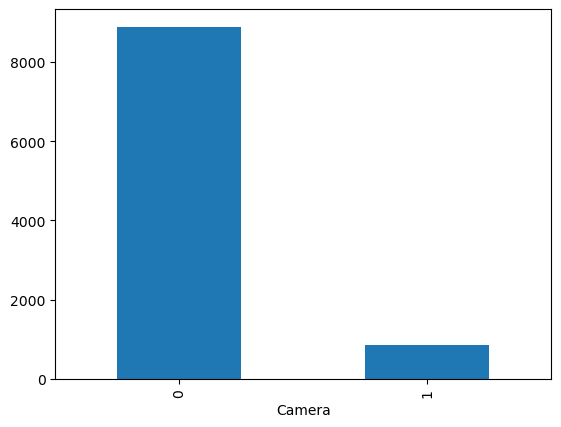

In [70]:
dataset["Camera"].value_counts().plot(kind = "bar")


The chart shows that most Roblox games do not support the camera feature. Approximately 4,200 games in the dataset have no camera support, while only about 850 games support camera functionality.

<Axes: xlabel='VoiceChat'>

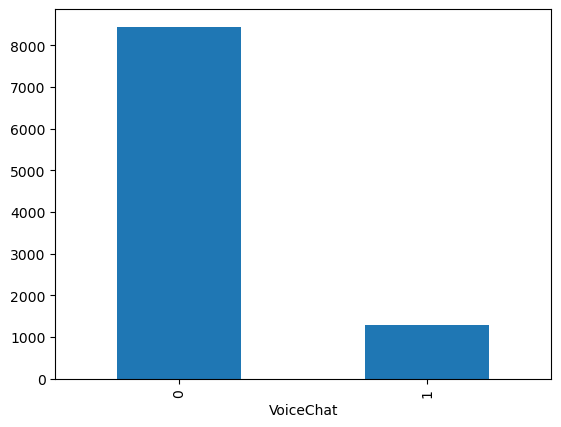

In [71]:
dataset["VoiceChat"].value_counts().plot(kind = "bar")

Similar to Camera, The chart shows that most Roblox games do not support the Voice Chat  feature. Approximately 3500 games in the dataset have no Voice Chat support, while only about 1500 games support Voice Chat  functionality.

<Axes: xlabel='AgeRecommendation'>

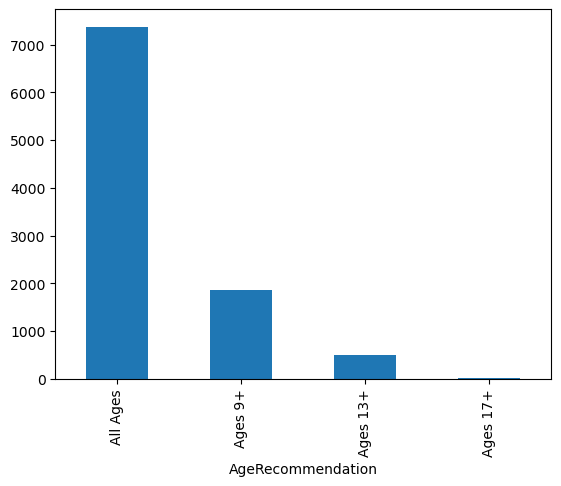

In [72]:
dataset["AgeRecommendation"].value_counts().plot(kind = "bar")


The chart indicates that the majority of Roblox games are designed for All Ages, making this the most common age recommendation in the dataset. Games recommended for Ages 9+ are the second most common.

<Axes: xlabel='Creator'>

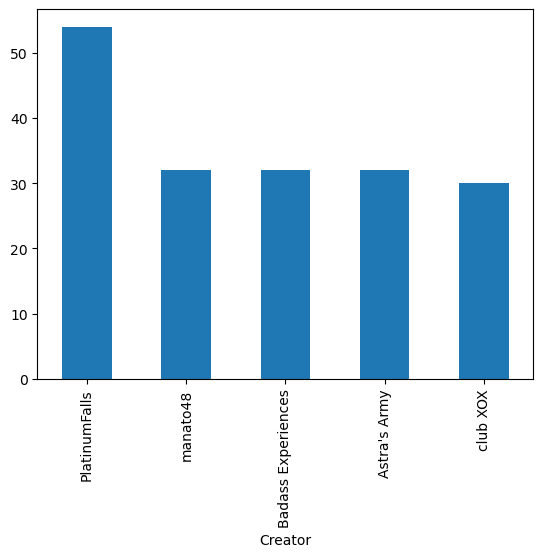

In [73]:
top_creatore = dataset['Creator'].value_counts().nlargest(5).plot(kind = 'bar')
top_creatore

The chart indicates that PlatinumFalls has created the largest number of games among all creators in the dataset, with approximately 28 games.

In [74]:
year = dataset['Created'].dt.year.value_counts()

<Axes: xlabel='Created'>

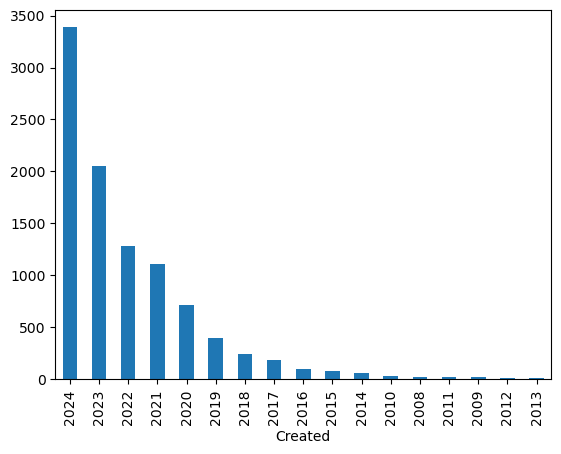

In [75]:
year.plot(kind = 'bar')

The chart shows that the number of Roblox games created has increased significantly over time. The highest number of games was created in 2024, followed by 2023 and 2022.it indicates a substantial increase in game development in recent years. This trend suggests that Roblox has experienced rapid growth

c:\Users\forev\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


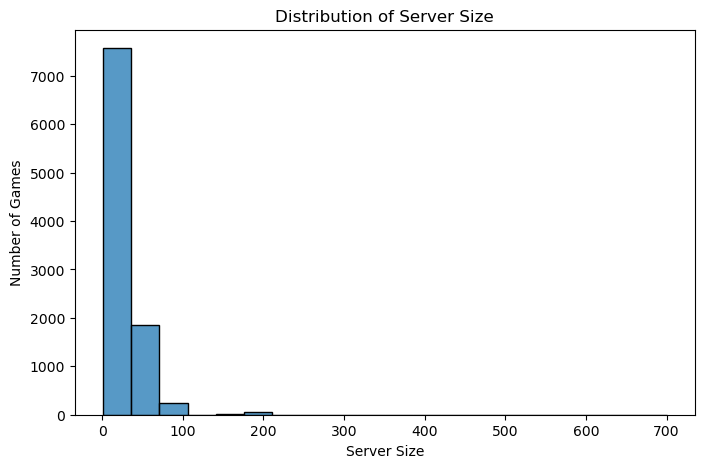

In [76]:
plt.figure(figsize=(8,5))
sns.histplot(dataset['ServerSize'], bins=20)

plt.title("Distribution of Server Size")
plt.xlabel("Server Size")
plt.ylabel("Number of Games")
plt.show()

The chart shows that most games operate on small servers, creating a heavily right-skewed distribution. The highest frequency of games is concentrated in the smallest size bracket, with a sharp decline as server size increases.

## Bivariate

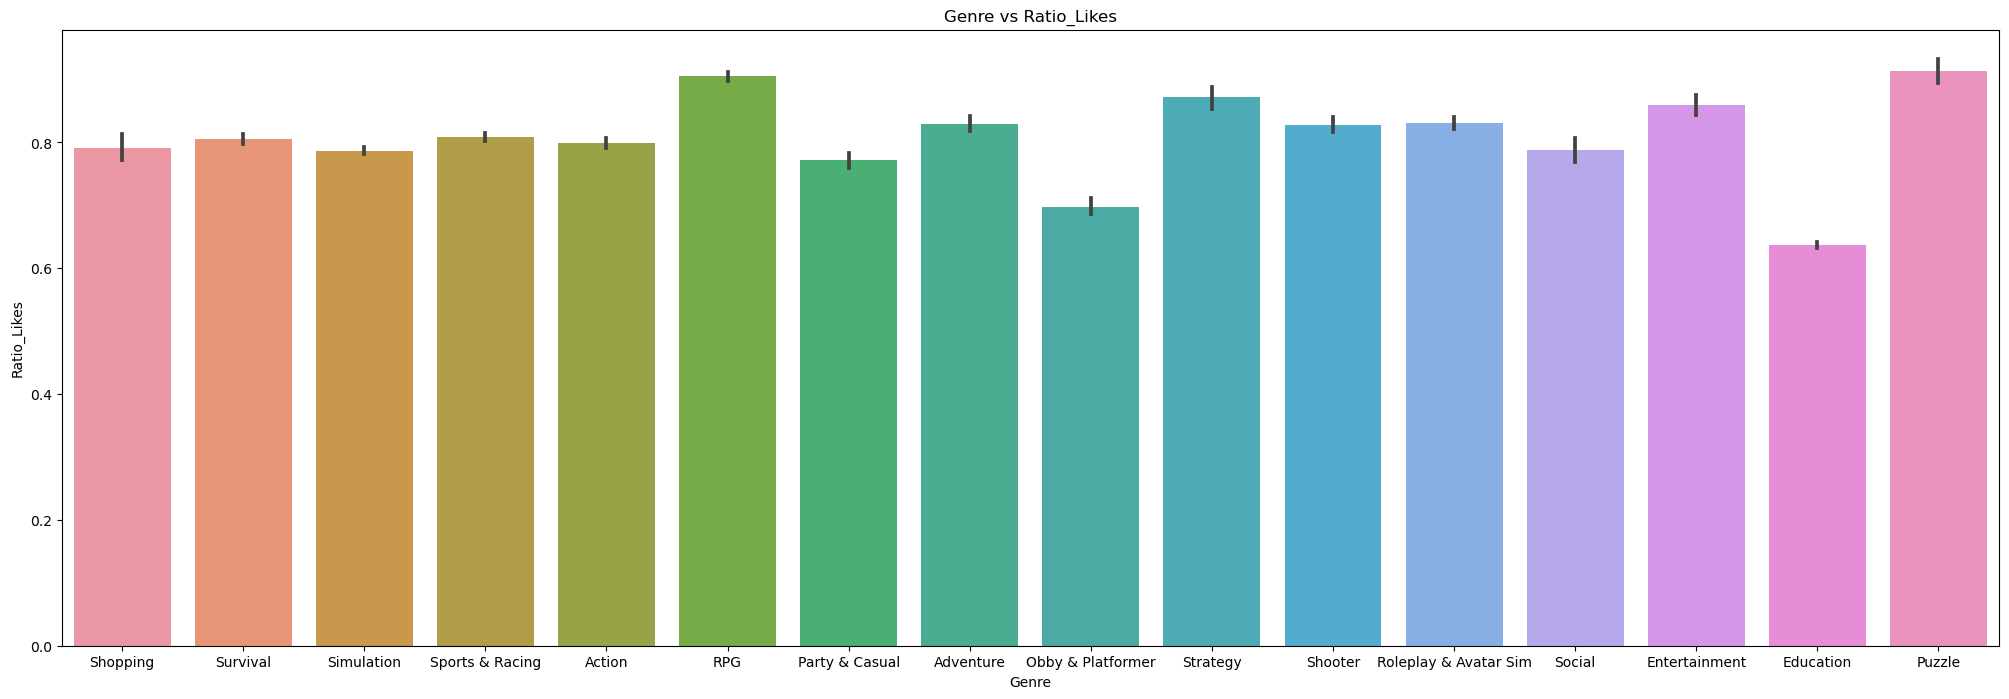

In [77]:
plt.figure(figsize =(25, 8))
sns.barplot(x = "Genre", y ="Ratio_Likes", data = dataset )
plt.title("Genre vs Ratio_Likes")
plt.show()

Puzzle and RPG genres have the highest like ratios, while Obby & Platformer and Education have the lowest.

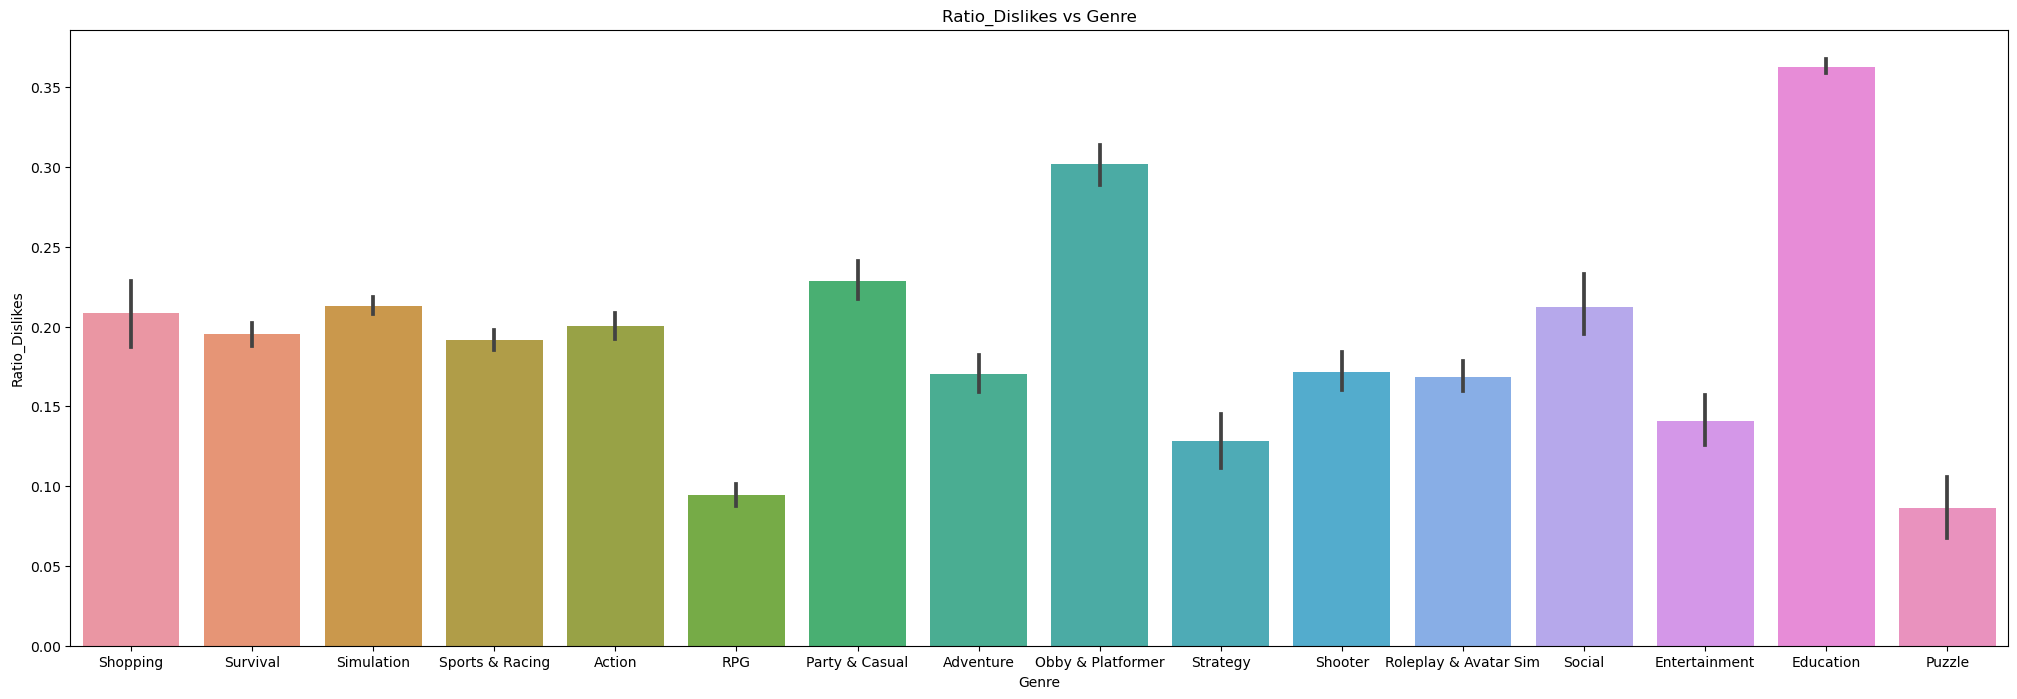

In [78]:


plt.figure(figsize =(25, 8))
sns.barplot(x = "Genre", y ="Ratio_Dislikes", data = dataset )
plt.title("Ratio_Dislikes vs Genre")
plt.show()

Education and Obby & Platformer having the highest dislike ratios. Conversely, Puzzle and RPG genres have the lowest dislike ratios.

In [79]:
fav_g = dataset.groupby('Genre')['Favorites'].count()

<Axes: xlabel='Genre'>

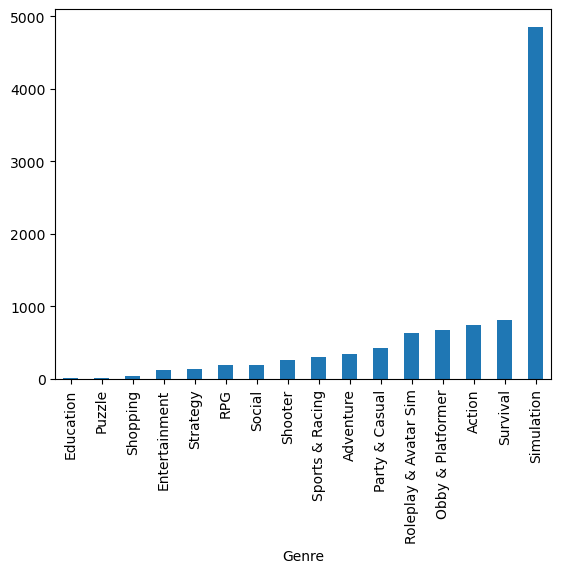

In [80]:
fav_g.sort_values().plot(kind = 'bar')

the number of Simulation games is exceptionally high compared to all others. This indicates that Simulation is the most dominant genre in terms of total game output.

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [Text(0, 0, 'Shopping'),
  Text(1, 0, 'Survival'),
  Text(2, 0, 'Simulation'),
  Text(3, 0, 'Sports & Racing'),
  Text(4, 0, 'Action'),
  Text(5, 0, 'RPG'),
  Text(6, 0, 'Party & Casual'),
  Text(7, 0, 'Adventure'),
  Text(8, 0, 'Obby & Platformer'),
  Text(9, 0, 'Strategy'),
  Text(10, 0, 'Shooter'),
  Text(11, 0, 'Roleplay & Avatar Sim'),
  Text(12, 0, 'Social'),
  Text(13, 0, 'Entertainment'),
  Text(14, 0, 'Education'),
  Text(15, 0, 'Puzzle')])

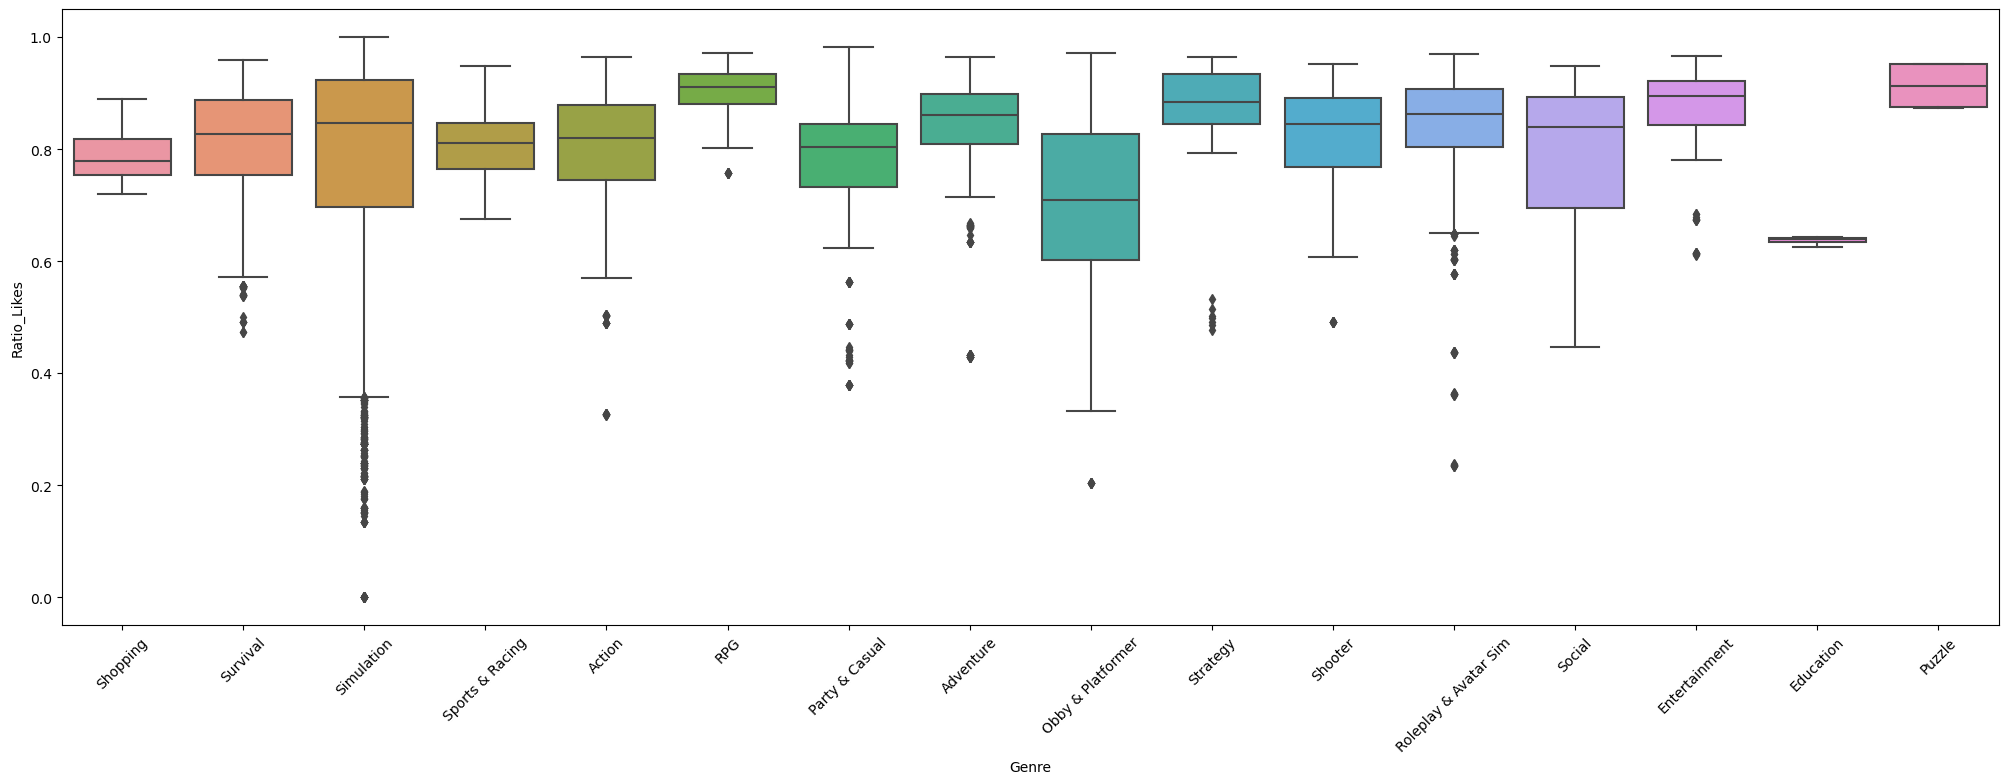

In [81]:
plt.figure(figsize=(25, 8))
sns.boxplot(data=dataset, x='Genre', y='Ratio_Likes')
plt.xticks(rotation=45)

the median "Ratio_Likes" is generally high across most genres, though consistency varies significantly. RPG and Puzzle genres exhibit high, stable satisfaction, while Simulation shows a wide range and many outliers, indicating highly polarized player experiences. This suggests that while most genres are well-received, some suffer from greater quality variability than others.

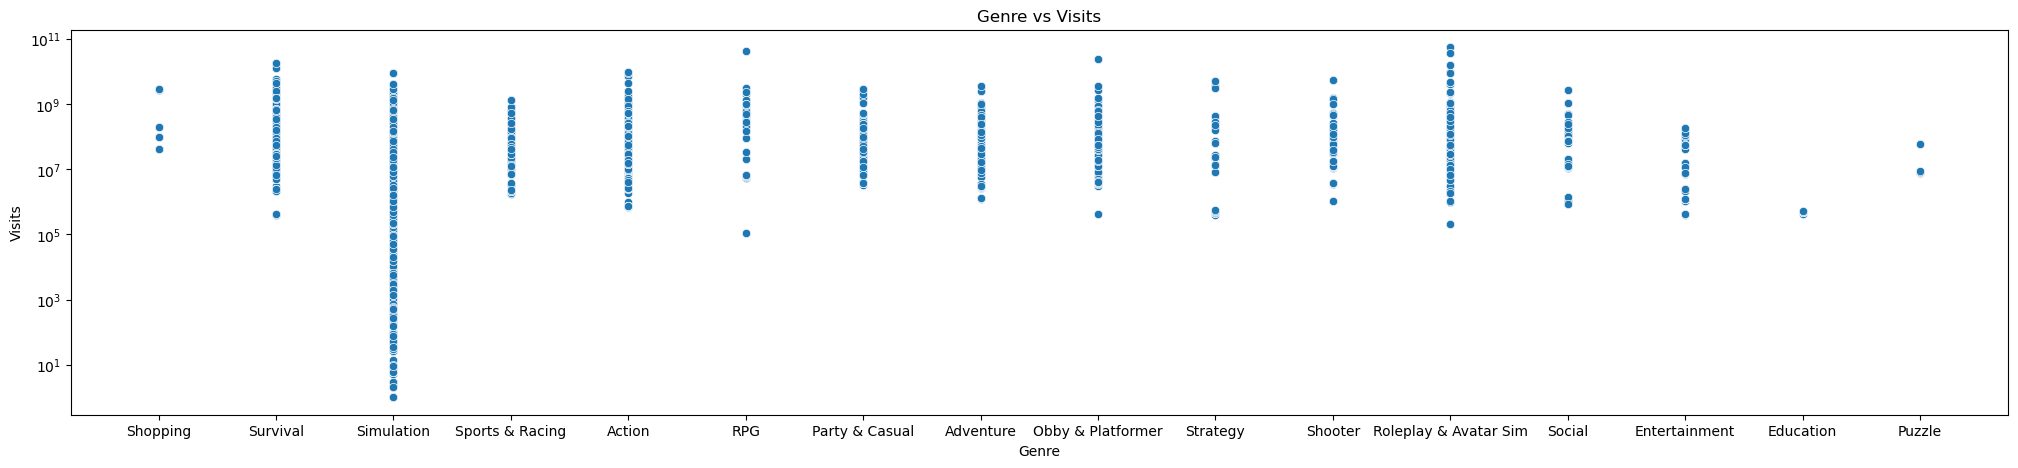

In [82]:
plt.figure(figsize=(25,5))

sns.scatterplot(
    data=dataset,
    x='Genre',
    y='Visits'
)
plt.yscale('log')

plt.title("Genre vs Visits")
plt.xlabel("Genre")
plt.ylabel("Visits")
plt.show()

most genres maintain a broad range of visit counts, specific categories like Roleplay & Avatar Sim, Survival, and Action frequently produce blockbuster titles with extremely high engagement.the graph highlights that Simulation has the highest density of games, spanning from very low to very high popularity

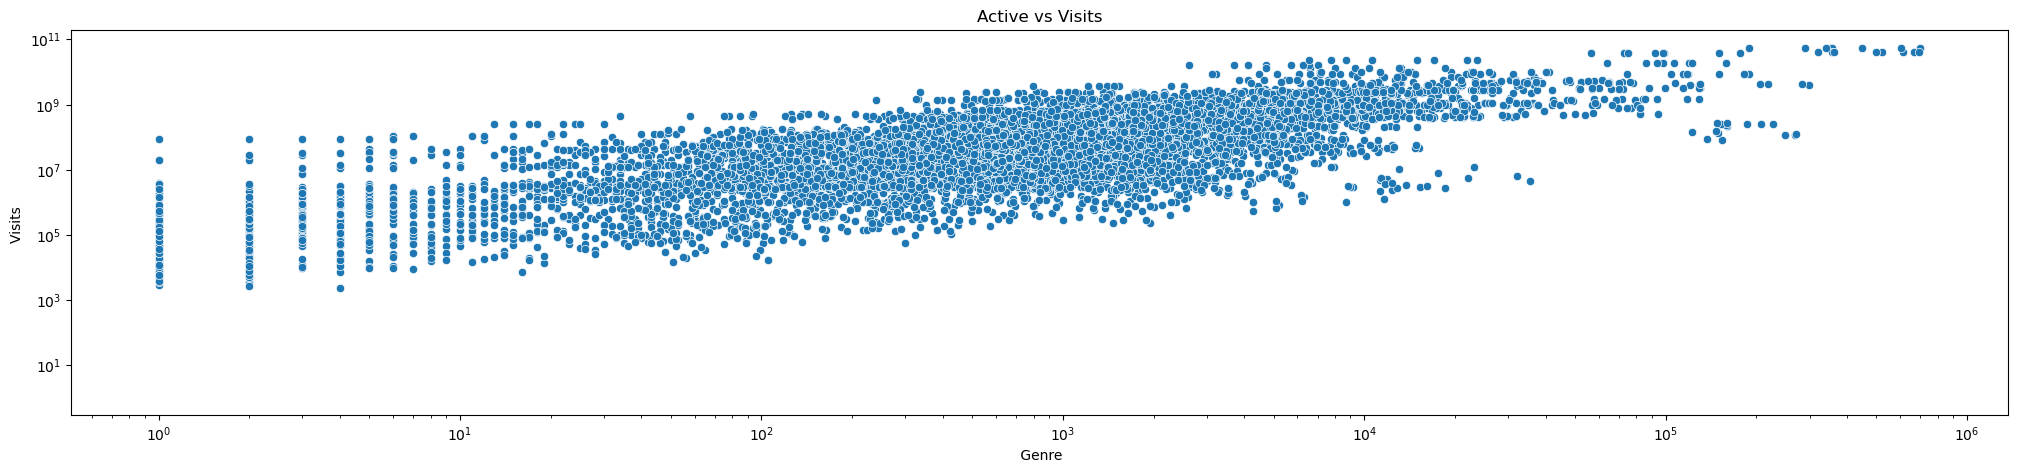

In [83]:
plt.figure(figsize=(25,5))

sns.scatterplot(
    data=dataset,
    x='Active',
    y='Visits'
)
plt.yscale('log')
plt.xscale('log')


plt.title("Active vs Visits")
plt.xlabel(" Genre")
plt.ylabel("Visits ")
plt.show()

The chart shows a strong positive correlation between active players and visits.As active user counts increase, total visits grow proportionally.This confirms that games with higher Visits retention predictably accumulate significantly more visits over time.

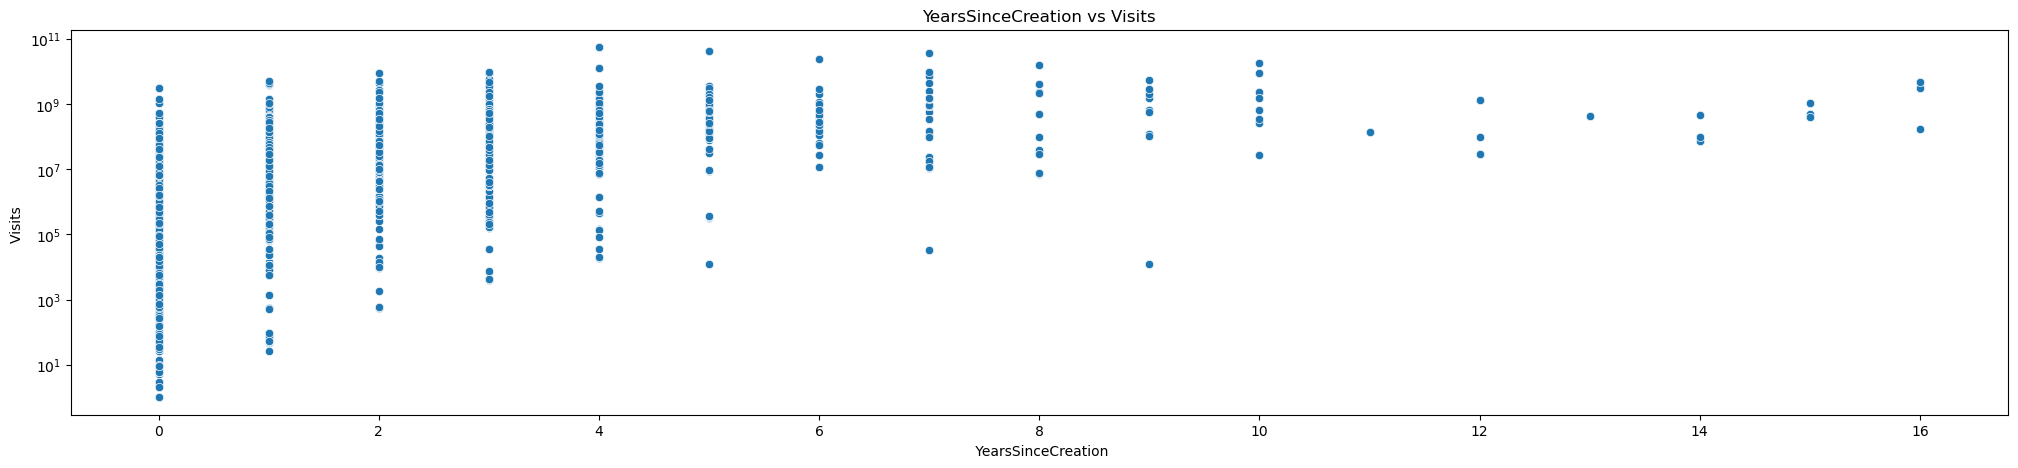

In [84]:
plt.figure(figsize=(25,5))

sns.scatterplot(
    data=dataset,
    x='YearsSinceCreation',
    y='Visits'
)
plt.yscale('log')



plt.title("YearsSinceCreation vs Visits")
plt.xlabel(" YearsSinceCreation")
plt.ylabel("Visits ")
plt.show()

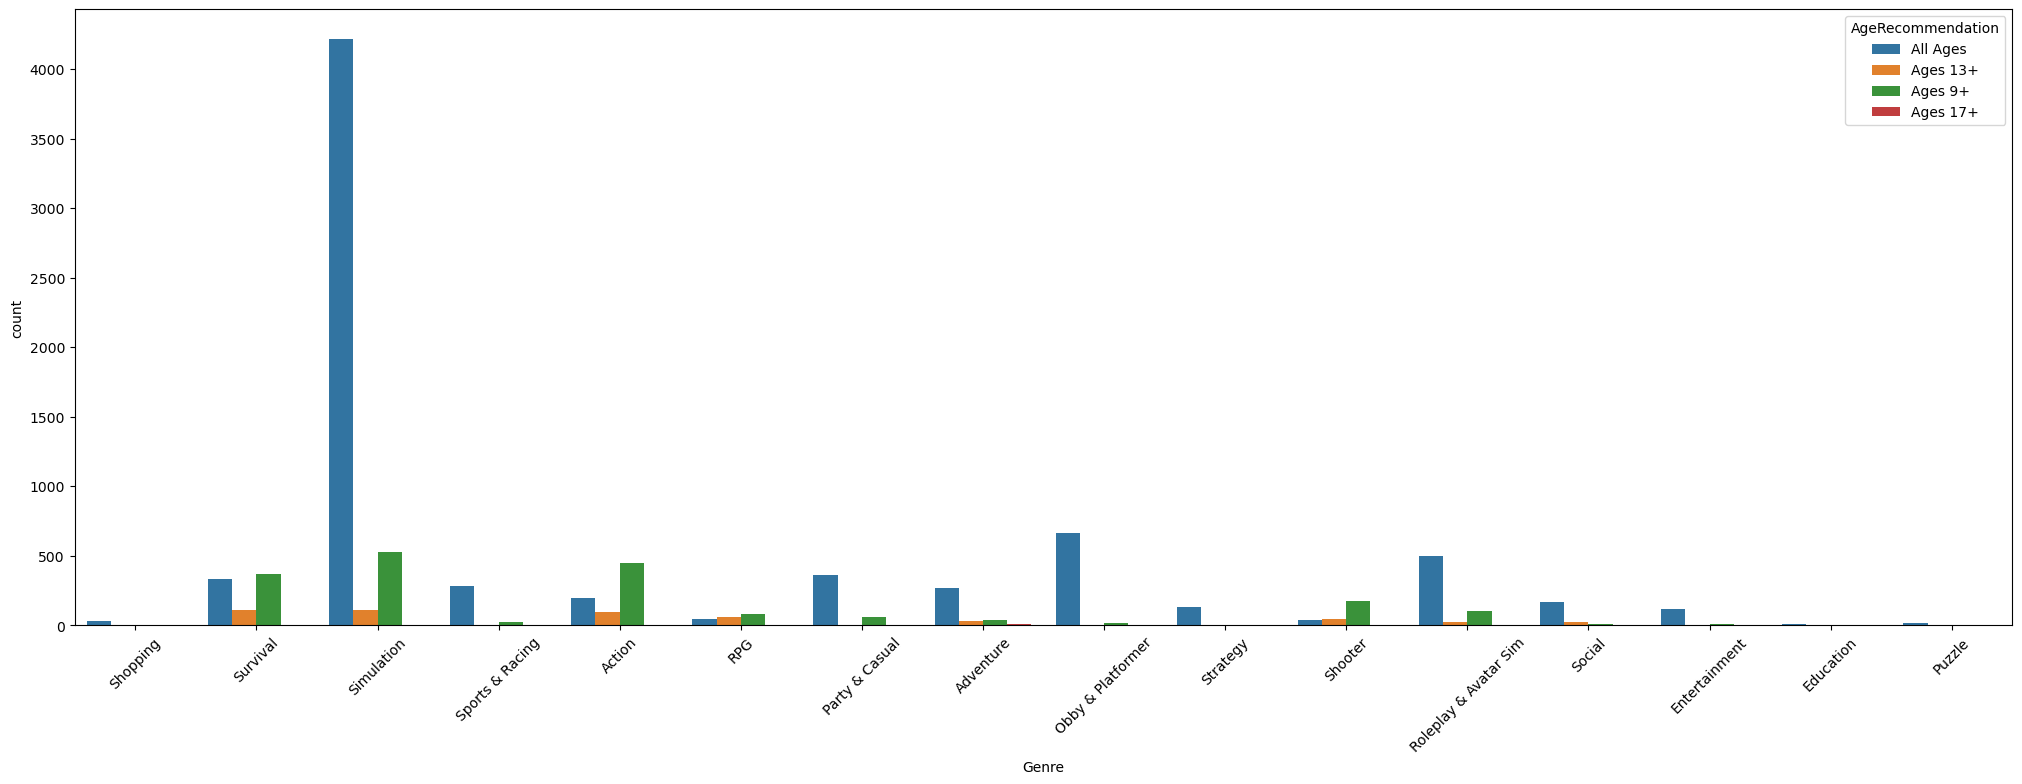

In [85]:
plt.figure(figsize=(25, 8))
sns.countplot(x = "Genre", hue = "AgeRecommendation", data = dataset )
plt.xticks(rotation = 45)
plt.show()

In [86]:
pd.crosstab(dataset["AgeRecommendation"], dataset["Genre"])


Genre,Action,Adventure,Education,Entertainment,Obby & Platformer,Party & Casual,Puzzle,RPG,Roleplay & Avatar Sim,Shooter,Shopping,Simulation,Social,Sports & Racing,Strategy,Survival
AgeRecommendation,,,,,,,,,,,,,,,,
Ages 13+,95,32,0,0,0,1,0,56,23,48,0,108,21,0,0,111
Ages 17+,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Ages 9+,449,40,0,8,16,57,0,82,104,175,0,527,8,24,0,370
All Ages,198,266,7,118,662,362,16,45,497,40,32,4220,166,280,133,329


Multivariate

<Axes: >

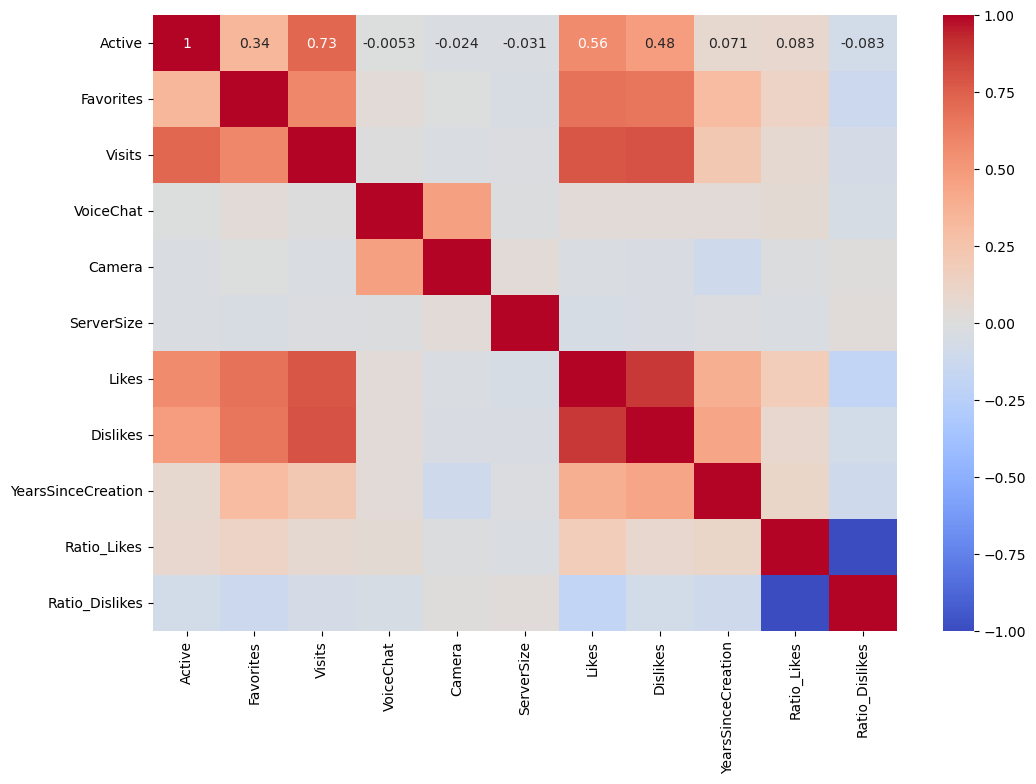

In [87]:
numeric = dataset.select_dtypes(include='number')

plt.figure(figsize=(12,8))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')

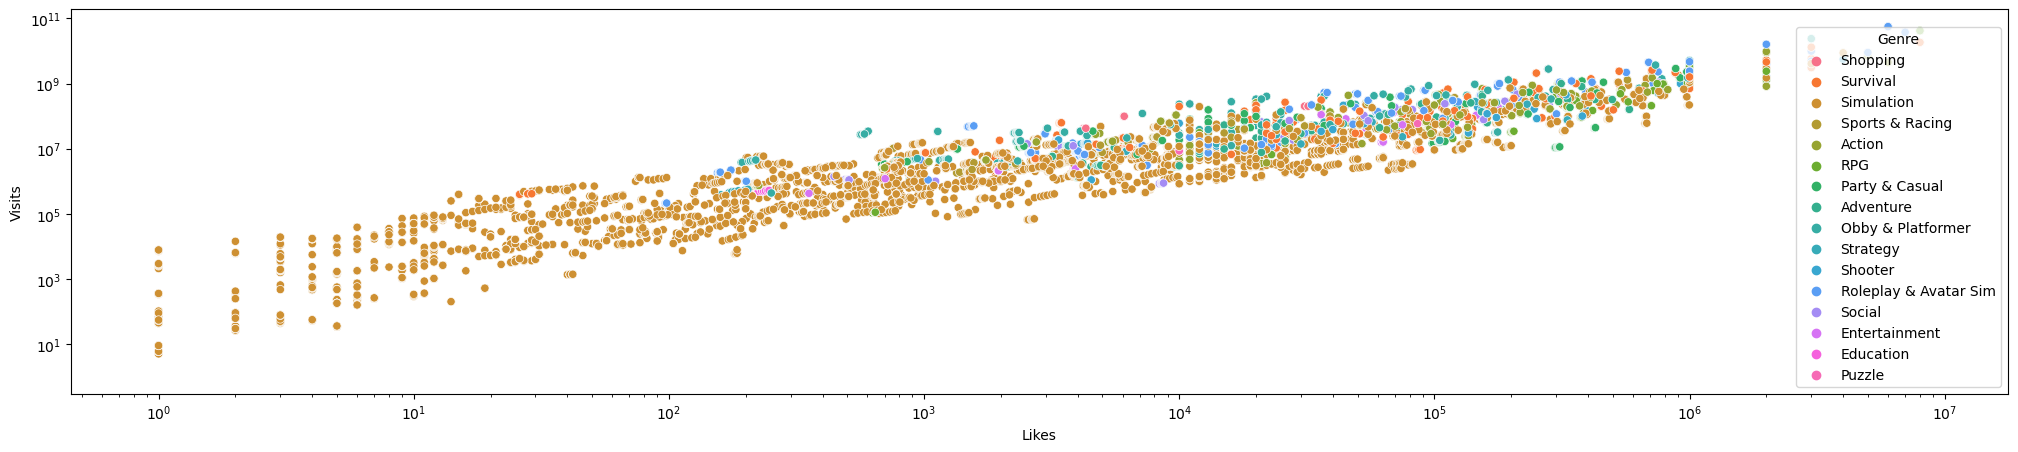

In [88]:
plt.figure(figsize=(25,5))
sns.scatterplot(
    data=dataset,
    x='Likes',
    y='Visits',
    hue='Genre'
)
plt.yscale('log')
plt.xscale('log')

Key Insights